# Learning an optimal distribution over the parameters of a neural network to approach a target function $f$.
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = f(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise and $f$ a target function. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [39]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq, recommended_kernel, matern_kernel
from modules.variational_inference import VariationalInference


import jax
from jax import random

In [ ]:
device_name = "cpu"
kernel_name = "recommended_kernel"

In [41]:
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

def init_params(key, input_dim, hidden_dim):
  subkey1, subkey2 = random.split(key)
  params = {
      'W1': random.normal(subkey1, (hidden_dim, input_dim)) * 1.0,
      'b1': jnp.zeros(hidden_dim),
      'W2': random.normal(subkey2, (1, hidden_dim)) * 1.0,
      'b2': jnp.zeros(1),
  }
  return params

@jit
def forward(params, z):
  h = jnp.tanh(jnp.dot(params['W1'], z) + params['b1'])  # hidden layer
  y = jnp.dot(params['W2'], h) + params['b2']             # scalar output
  return y.squeeze()

def forward_(X, z, unravel_fn):
  E = jnp.mean(jit(vmap(lambda x : forward(unravel_fn(x), z)))(X))
  return E

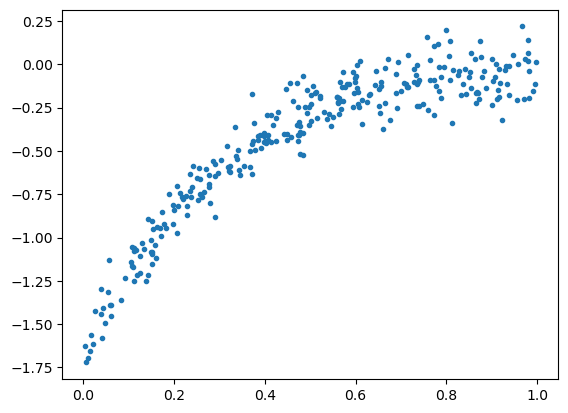

In [42]:
def generate_data(key, s, N=300, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [0,1]

    def target_function(z):
        params = jnp.array([2, 0.5, 3, -3])
        return params[2]*jnp.tanh(params[0]*z.squeeze()+params[1]) + params[3]

    Y_clean = target_function(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

s = 1 #input dimension
key = random.PRNGKey(1003)
key, subkey = random.split(key)
N = 300
Z_train, Y_train = generate_data(subkey, s, N=N, noise_std=0.1) # put more noise
key, subkey = random.split(key)
Z_test, Y_test = generate_data(subkey, s, N=N, noise_std=0.1)

device = jax.devices()[0]
Z_train, Y_train = jax.device_put((Z_train, Y_train), device)
plt.plot(Z_train, Y_train, ".")

In [ ]:

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*0.5))

def grad_log_q0(X):
    return -X/0.5

def L(X, unravel_fn, gamma):
    Esp_forward = vmap(lambda z: forward_(X, z, unravel_fn))(Z_train)
    return gamma * jnp.mean((Esp_forward - Y_train) ** 2) #+ lambd * 1/n * jnp.sum(X ** 2)

# This part is required to obtain unravel_fn
hidden_dim = 1
params = init_params(key, s, hidden_dim)
params = jax.device_put(params, device)
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)

gamma = 300
L_ = jit(lambda X: L(X, unravel_fn, gamma))


scale = 0.3
k_vi = jit(lambda x, y: k_imq(x, y, 1, 1, scale))

learning_rate = 1e-3
VI = VariationalInference(grad_log_q0, L_, k_vi, d, 20, learning_rate) 

In [25]:
T = 20000
n = 100

key = random.PRNGKey(31)
all_particles = jnp.array(VI.run_particles(key,T,n,gamma = gamma))
X_fin = all_particles[-1]

  0%|          | 13/20000 [00:00<15:25, 21.60it/s] 

Step 0, Loss: 598.3927612304688, MSE 0.3151663541793823, Grad 181.3445281982422


  5%|▌         | 1014/20000 [00:10<03:43, 84.94it/s]

Step 1000, Loss: 249.386474609375, MSE 0.052810657769441605, Grad 4.087612628936768


 10%|█         | 2001/20000 [00:20<03:33, 84.20it/s] 

...

 90%|█████████ | 18018/20000 [02:48<00:18, 108.16it/s]

Step 18000, Loss: 28.7744197845459, MSE 0.018093861639499664, Grad 0.07533860206604004


 95%|█████████▌| 19012/20000 [03:01<00:14, 67.94it/s] 

Step 19000, Loss: 30.595605850219727, MSE 0.018463926389813423, Grad 0.055042121559381485


100%|██████████| 20000/20000 [03:11<00:00, 104.32it/s]


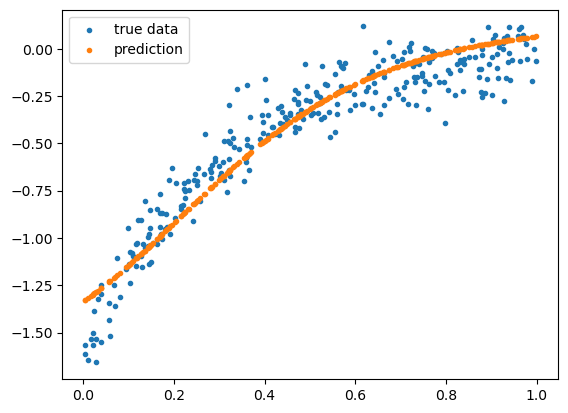

In [26]:
#Prediction function 
plt.scatter(Z_test,Y_test,label = "true data",marker = ".")
Y_hat = vmap(lambda z: forward_(X_fin, z, unravel_fn))(Z_test)
plt.scatter(Z_test,Y_hat,label = "prediction",marker = ".")
plt.legend()

Text(0, 0.5, 'dim4')

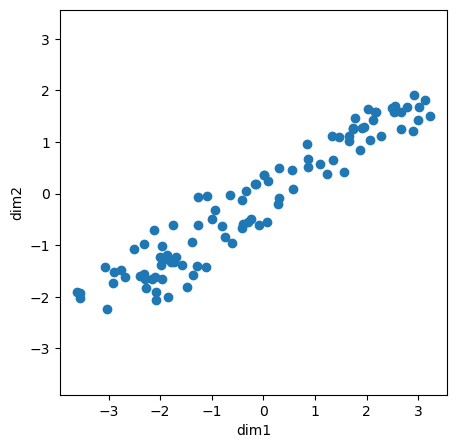

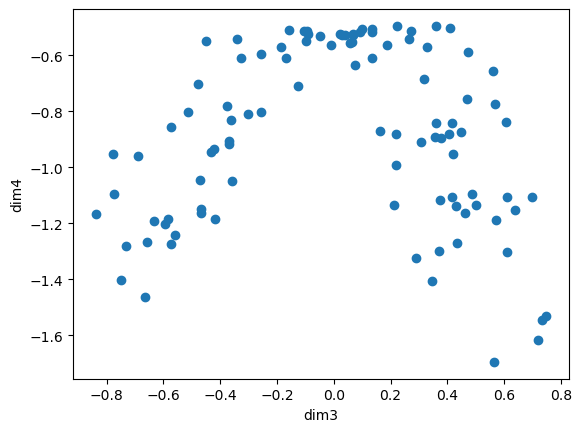

In [27]:
#Final particles positions
plt.figure(figsize = (5,5))
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.xlabel("dim1")
plt.ylabel("dim2")
plt.axis('equal')
plt.figure()
plt.scatter(X_fin[:,2], X_fin[:,3])
plt.xlabel("dim3")
plt.ylabel("dim4")

In [28]:
import jax.numpy as jnp
import pickle

expe2_filename_evol_particles = f"saved_data/expe2_evol_particles_{kernel_name}.pkl"
# load
with open(expe2_filename_evol_particles, "rb") as g:
    expe2_evol_particles = pickle.load(g)

In [12]:
iterations_gradL = jnp.array([1,10**3,10**4,10**5,2*10**6])
particles_position = all_particles[iterations_gradL//n,:,:]
expe2_evol_particles["Variational Inference"]["iterations_gradL"] = iterations_gradL
expe2_evol_particles["Variational Inference"]["particles_position"] = particles_position

In [13]:
import pickle

# Save
with open(expe2_filename_evol_particles, "wb") as gg:
    pickle.dump(expe2_evol_particles, gg)

KGD evolution

Text(0.5, 1.0, 'KGD values over iterations')

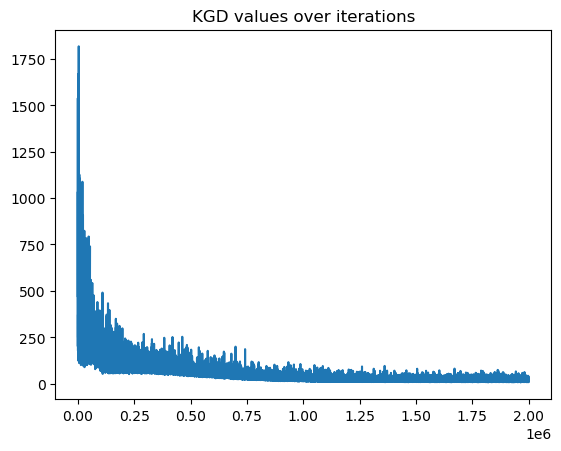

In [58]:

if kernel_name == "imq":
    scale = 0.1
    k = jit(lambda x, y: k_imq(x, y, 1, 0.5, scale))
elif kernel_name == "recommended_kernel":
    l = jit(lambda x, y: k_imq(x, y, 1, 5.0))#matern_kernel(x,y,5.0))
    alpha = 2.0
    beta = 1.0
    k = lambda x,y : recommended_kernel(x,y,l,alpha,beta,1.0)

k_pq = GradientKernel(VI.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
eval_gradL = jnp.arange(0,T)*n
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))
plt.plot(eval_gradL,KGD_values)
plt.title("KGD values over iterations")

# Save data

In [59]:
import jax.numpy as jnp
import pickle

filename = f"saved_data/expe2_results_{kernel_name}.pkl"
# load file
with open(filename, "rb") as g:
    expe2_results = pickle.load(g)

In [60]:
expe2_results["Variational Inference"]["X_fin"] = X_fin
expe2_results["Variational Inference"]["KGD_values"] = KGD_values
expe2_results["Variational Inference"]["gradL_eval"] = eval_gradL
expe2_results["kernel"] = kernel_name

In [61]:
import pickle

# Save results
with open(filename, "wb") as gg:
    pickle.dump(expe2_results, gg)